In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula.api import ols
import statsmodels.api as sm
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS, RandomEffects
from linearmodels.panel import compare
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import zscore, chi2
from statsmodels.tsa.stattools import adfuller, kpss
from google.colab import files
import io

Please upload your dataset file (Excel, CSV etc.):


Saving India_All_States_Power_Economy_2015_2025.xlsx to India_All_States_Power_Economy_2015_2025 (8).xlsx
Loaded file: India_All_States_Power_Economy_2015_2025 (8).xlsx

Data Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396 entries, 0 to 395
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   State                          396 non-null    object 
 1   Year                           396 non-null    int64  
 2   Renewable Energy Share (%)     396 non-null    float64
 3   GDP Growth Rate (%)            396 non-null    float64
 4   Capacity Utilization Rate (%)  396 non-null    float64
 5   Fuel Price Index               396 non-null    float64
 6   Electricity Demand Growth (%)  396 non-null    float64
 7   Average Tariff (Rs/unit)       396 non-null    float64
 8   Profit Margin (%)              396 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage

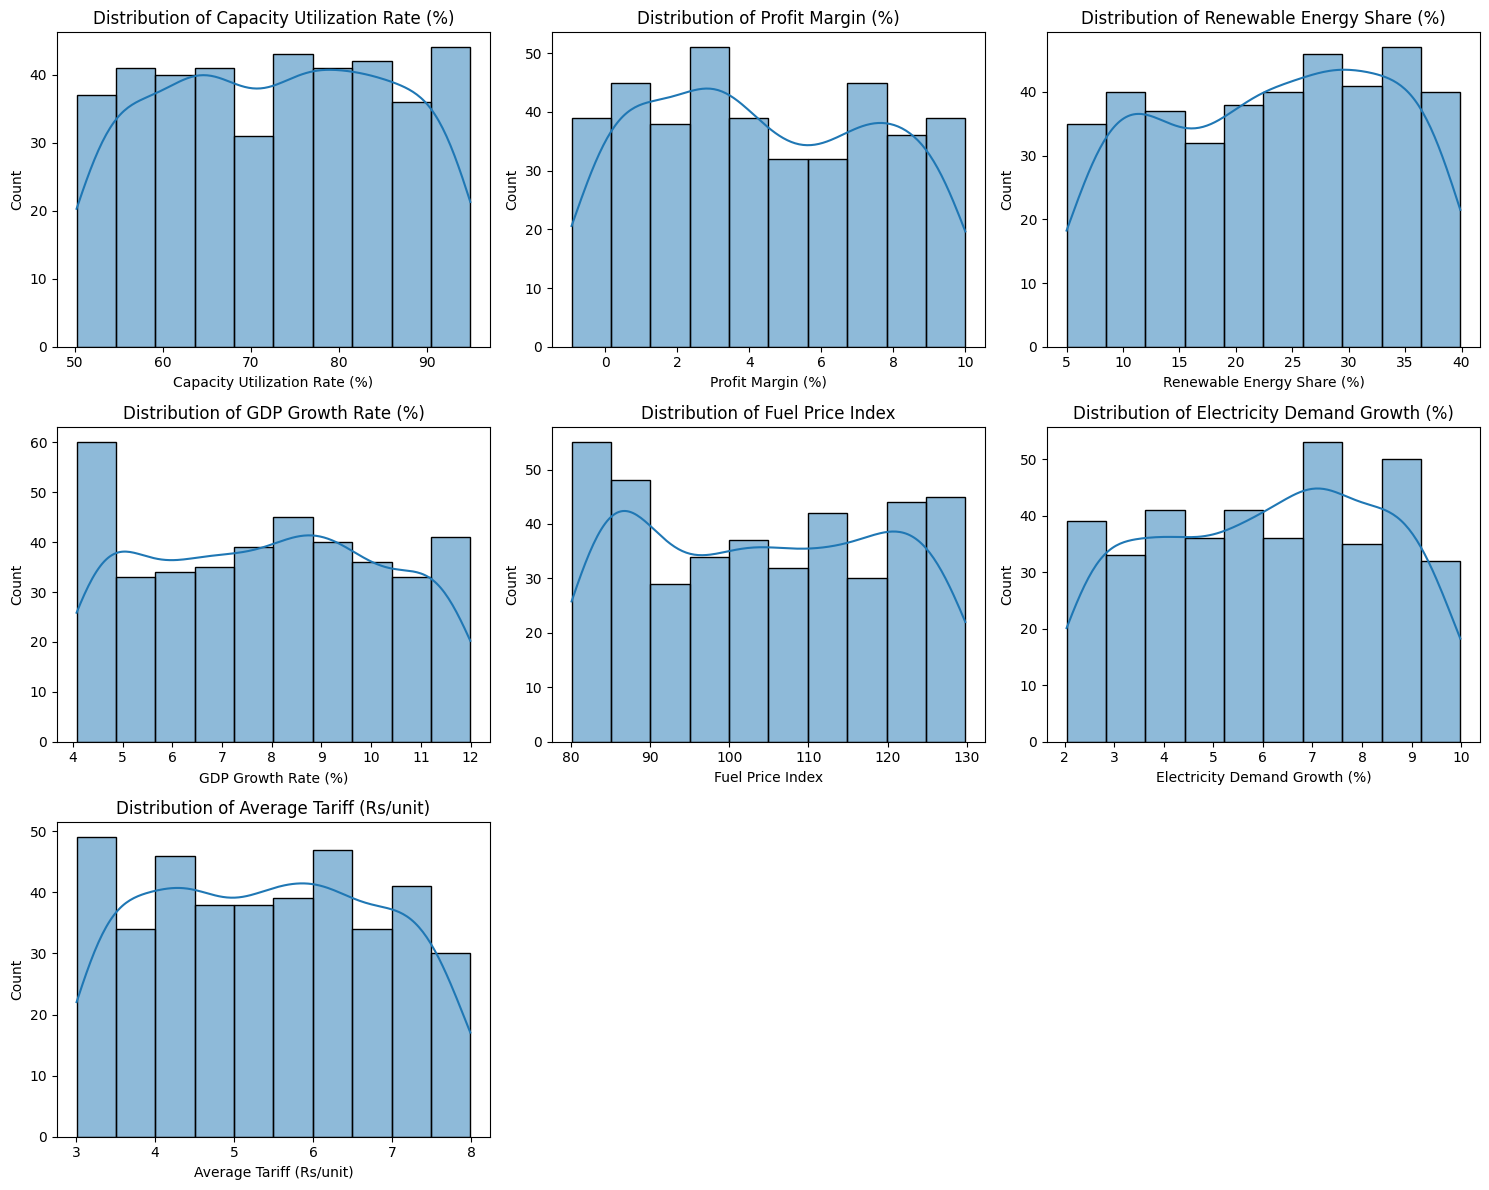


Correlation Matrix:
                               Capacity Utilization Rate (%)  \
Capacity Utilization Rate (%)                       1.000000   
Profit Margin (%)                                  -0.029460   
Renewable Energy Share (%)                          0.036159   
GDP Growth Rate (%)                                -0.017164   
Fuel Price Index                                   -0.019589   
Electricity Demand Growth (%)                      -0.070822   
Average Tariff (Rs/unit)                            0.076646   

                               Profit Margin (%)  Renewable Energy Share (%)  \
Capacity Utilization Rate (%)          -0.029460                    0.036159   
Profit Margin (%)                       1.000000                    0.011744   
Renewable Energy Share (%)              0.011744                    1.000000   
GDP Growth Rate (%)                    -0.045678                    0.009138   
Fuel Price Index                       -0.055214                  

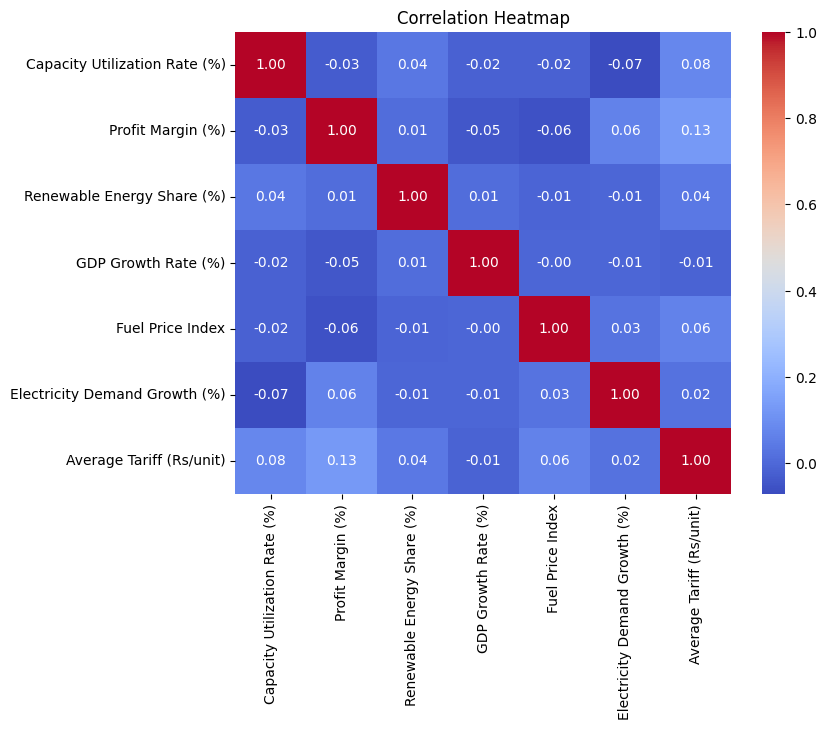


Variance Inflation Factor (VIF):
                         feature        VIF
0                          const  81.754035
1     Renewable Energy Share (%)   1.002026
2            GDP Growth Rate (%)   1.000304
3               Fuel Price Index   1.004990
4  Electricity Demand Growth (%)   1.001153
5       Average Tariff (Rs/unit)   1.006547

Stationarity Test Summary (ADF and KPSS) for Dependent Variables by State:
                          State             Dependent Variable  \
0   Andaman and Nicobar Islands  Capacity Utilization Rate (%)   
1   Andaman and Nicobar Islands              Profit Margin (%)   
2                Andhra Pradesh  Capacity Utilization Rate (%)   
3                Andhra Pradesh              Profit Margin (%)   
4             Arunachal Pradesh  Capacity Utilization Rate (%)   
..                          ...                            ...   
67                Uttar Pradesh              Profit Margin (%)   
68                  Uttarakhand  Capacity Utilization 

/tmp/ipython-input-4269277623.py:78: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, _, _ = kpss(series.dropna(), nlags="auto")
/tmp/ipython-input-4269277623.py:78: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, _, _ = kpss(series.dropna(), nlags="auto")
/tmp/ipython-input-4269277623.py:78: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, _, _ = kpss(series.dropna(), nlags="auto")
/tmp/ipython-input-4269277623.py:78: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value 


Fixed Effects Model Summary:
                                PanelOLS Estimation Summary                                
Dep. Variable:     Capacity Utilization Rate (%)   R-squared:                        0.9574
Estimator:                              PanelOLS   R-squared (Between):              0.9957
No. Observations:                            396   R-squared (Within):              -0.4008
Date:                           Thu, Nov 20 2025   R-squared (Overall):              0.9574
Time:                                   12:10:10   Log-likelihood                   -1641.3
Cov. Estimator:                        Clustered                                           
                                                   F-statistic:                      1756.2
Entities:                                     36   P-value                           0.0000
Avg Obs:                                  11.000   Distribution:                   F(5,391)
Min Obs:                                  11.000  

In [ ]:
# Upload dataset
print("Please upload your dataset file (Excel, CSV etc.):")
uploaded = files.upload()
for filename in uploaded.keys():
    print(f"Loaded file: {filename}")

# Adjust according to actual file extension and sheet name if Excel
if filename.endswith('.xlsx'):
    df = pd.read_excel(io.BytesIO(uploaded[filename]))
else:
    df = pd.read_csv(io.BytesIO(uploaded[filename]))

# Step 2: Initial Data Overview
print("\nData Summary:")
print(df.info())
print(df.head())

# Step 3: Preprocessing - set panel structure and convert Year to int if needed
df['Year'] = df['Year'].astype(int)
df = df.set_index(['State', 'Year']).sort_index()

# Step 4: Exploratory Data Analysis (EDA)

# 4a. Summary statistics for all variables
print("\nSummary Statistics:")
print(df.describe())

# 4b. Outlier detection using z-score > |3| for numeric variables
numeric_cols = df.select_dtypes(include=[np.number]).columns
z_scores = df[numeric_cols].apply(zscore)
outliers = (np.abs(z_scores) > 3)
print("\nOutliers detected (z-score > 3):")
print(outliers.sum())

# 4c. Distribution plots for dependent and independent variables
import math
cols_to_plot = ['Capacity Utilization Rate (%)', 'Profit Margin (%)',
                'Renewable Energy Share (%)', 'GDP Growth Rate (%)',
                'Fuel Price Index', 'Electricity Demand Growth (%)',
                'Average Tariff (Rs/unit)']
n_cols = 3
n_rows = math.ceil(len(cols_to_plot) / n_cols)
plt.figure(figsize=(5*n_cols,4*n_rows))
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# 4d. Correlation matrix and heatmap
corr = df[cols_to_plot].corr()
print("\nCorrelation Matrix:")
print(corr)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# 4e. Multicollinearity check - Variance Inflation Factor (VIF)
X = df[['Renewable Energy Share (%)', 'GDP Growth Rate (%)', 'Fuel Price Index', 'Electricity Demand Growth (%)', 'Average Tariff (Rs/unit)']]
X = sm.add_constant(X)
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\nVariance Inflation Factor (VIF):")
print(vif_data)

# 4f. Time series stationarity tests by State for dependent variables
def adf_test(series, signif=0.05, name='', verbose=False):
    r = adfuller(series.dropna(), autolag='AIC')
    p_value = r[1]
    if verbose:
        print(f'ADF Test on "{name}" - p-value: {p_value}')
    return p_value < signif

def kpss_test(series, signif=0.05, name='', verbose=False):
    statistic, p_value, _, _ = kpss(series.dropna(), nlags="auto")
    if verbose:
        print(f'KPSS Test on "{name}" - p-value: {p_value}')
    return p_value > signif  # Null: series is stationary

print("\nStationarity Test Summary (ADF and KPSS) for Dependent Variables by State:")
states = df.index.get_level_values(0).unique()
stationarity_results = []
for state in states:
    sub_df = df.loc[state]
    for dep_var in ['Capacity Utilization Rate (%)', 'Profit Margin (%)']:
        adf_stationary = adf_test(sub_df[dep_var], name=f"{dep_var} - {state}")
        kpss_stationary = kpss_test(sub_df[dep_var], name=f"{dep_var} - {state}")
        stationarity_results.append({
            'State': state,
            'Dependent Variable': dep_var,
            'ADF Stationary': adf_stationary,
            'KPSS Stationary': kpss_stationary
        })
stationarity_df = pd.DataFrame(stationarity_results)
print(stationarity_df)

# Step 5: Model Estimation - Fixed Effects and Random Effects for each dependent variable

# Function to format column names for formulas (wrap in backticks if special characters are present)
def format_formula_col(col_name):
    if any(char in col_name for char in ['(', ')', '%', ' ', '-', '/', '.', '[', ']']):
        return f"`{col_name}`"
    return col_name

# Define model formula
independent_vars = ['Renewable Energy Share (%)', 'GDP Growth Rate (%)', 'Fuel Price Index',
                    'Electricity Demand Growth (%)', 'Average Tariff (Rs/unit)']
independent_vars_formatted = [format_formula_col(col) for col in independent_vars]
formula = "{} ~ " + " + ".join(independent_vars_formatted)

# Removed custom hausman function

results = {}
for dep_var in ['Capacity Utilization Rate (%)', 'Profit Margin (%)']:
    print(f"\n=== Dependent Variable: {dep_var} ===")

    # Format dependent variable name for the formula
    formatted_dep_var = format_formula_col(dep_var)

    # Fixed Effects Model (within estimator)
    fe_mod = PanelOLS.from_formula(formula.format(formatted_dep_var), df, drop_absorbed=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print("\nFixed Effects Model Summary:")
    print(fe_res.summary)

    # Random Effects Model
    re_mod = RandomEffects.from_formula(formula.format(formatted_dep_var), df)
    re_res = re_mod.fit(cov_type='clustered', cluster_entity=True)
    print("\nRandom Effects Model Summary:")
    print(re_res.summary)

    # Hausman Test using linearmodels.panel.compare
    hausman_results = compare({'FE': fe_res, 'RE': re_res})

    if hasattr(hausman_results, 'hausman') and hausman_results.hausman is not None:
        stat = hausman_results.hausman.stat
        pval = hausman_results.hausman.pval
        preferred = "Fixed Effects" if pval < 0.05 else "Random Effects"
    else:
        stat = float('nan')
        pval = float('nan')
        preferred = "Undetermined (Hausman test not computable)"
        print("Warning: Hausman test could not be computed. This often happens if the covariance matrix difference is not positive definite, making the test invalid.")

    print(f"\nHausman Test Statistic: {stat:.4f}, p-value: {pval:.4f}")
    print(f"Preferred Model: {preferred}")
    results[dep_var] = {'FE': fe_res, 'RE': re_res, 'Hausman p-value': pval, 'Preferred': preferred}

# Step 6: Residual Diagnostics and Visualization for Fixed Effects (Preferred Model)
for dep_var, res_dict in results.items():
    print(f"\nResidual analysis and diagnostics for {dep_var} - {res_dict['Preferred']} model")

    # Only proceed if a specific preferred model was determined
    if res_dict['Preferred'] in ['Fixed Effects', 'Random Effects']:
        # Select the model results based on the preferred model (first two characters 'FE' or 'RE')
        model_res = res_dict[res_dict['Preferred'][:2]]

        # Residual plot
        residuals = model_res.resids
        plt.figure(figsize=(10,4))
        sns.histplot(residuals, kde=True)
        plt.title(f'Residual Distribution for {dep_var} ({res_dict["Preferred"]})')
        plt.show()

        # Plot fixed effects (if FE selected)
        if res_dict['Preferred'] == 'Fixed Effects':
            fe_params = model_res.params.filter(like='EntityEffects')
            if not fe_params.empty:
                plt.figure(figsize=(12,6))
                fe_params.plot(kind='bar')
                plt.title(f'Fixed Effects across States for {dep_var}')
                plt.xlabel('State')
                plt.ylabel('Fixed Effect')
                plt.show()
    else:
        print(f"Skipping residual analysis for {dep_var} as the preferred model is {res_dict['Preferred']}.")

# Step 7: Robustness Checks

# 7a. Clustered robust standard errors on preferred models already used above.

# 7b. Dynamic Panel Model with Lagged Dependent Variable (only FE model)
print("\n--- Dynamic Panel Model Residuals ---")
for dep_var in ['Capacity Utilization Rate (%)', 'Profit Margin (%)']:
    print(f"\nDynamic Panel Model (Lagged DV) for {dep_var}:")
    formatted_dep_var = format_formula_col(dep_var)
    df[f'lag_{dep_var}'] = df.groupby(level=0)[dep_var].shift(1)
    # Ensure the lagged dependent variable is also formatted correctly if it contains special characters.
    # Given how it's constructed, it likely won't, but for consistency and future proofing:
    formatted_lag_dep_var = format_formula_col(f'lag_{dep_var}')
    formula_dyn = f"{formatted_dep_var} ~ {formatted_lag_dep_var} + " + " + ".join(independent_vars_formatted)

    dyn_mod = PanelOLS.from_formula(formula_dyn, df.dropna(), drop_absorbed=True)
    dyn_res = dyn_mod.fit(cov_type='clustered', cluster_entity=True)
    print(dyn_res.summary)
    results[dep_var]['Dynamic'] = dyn_res # Store dynamic model results

# 7c. Alternative Model Specifications
# Example: Interaction term between Renewable Energy Share and GDP Growth Rate
print("\nAlternative Model with Interaction Term (Renewable Energy Share (%) * GDP Growth Rate (%))")
df['RE_GDP_interaction'] = df['Renewable Energy Share (%)'] * df['GDP Growth Rate (%)']
alt_independent_vars = independent_vars + ['RE_GDP_interaction']
alt_independent_vars_formatted = [format_formula_col(col) for col in alt_independent_vars]
formula_alt = "{} ~ " + " + ".join(alt_independent_vars_formatted)

for dep_var in ['Capacity Utilization Rate (%)', 'Profit Margin (%)']:
    formatted_dep_var = format_formula_col(dep_var)
    alt_mod = PanelOLS.from_formula(formula_alt.format(formatted_dep_var), df.dropna(), drop_absorbed=True)
    alt_res = alt_mod.fit(cov_type='clustered', cluster_entity=True)
    print(f"\nAlternative Model Summary for {dep_var}:")
    print(alt_res.summary)


--- Residual Diagnostics for Dynamic Panel Models ---


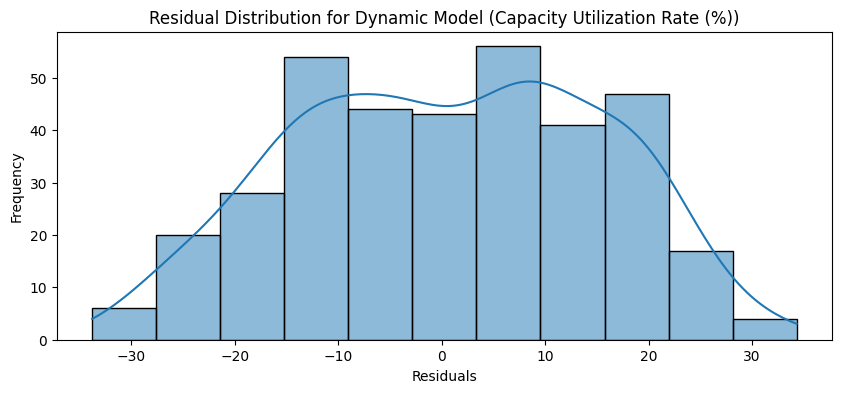

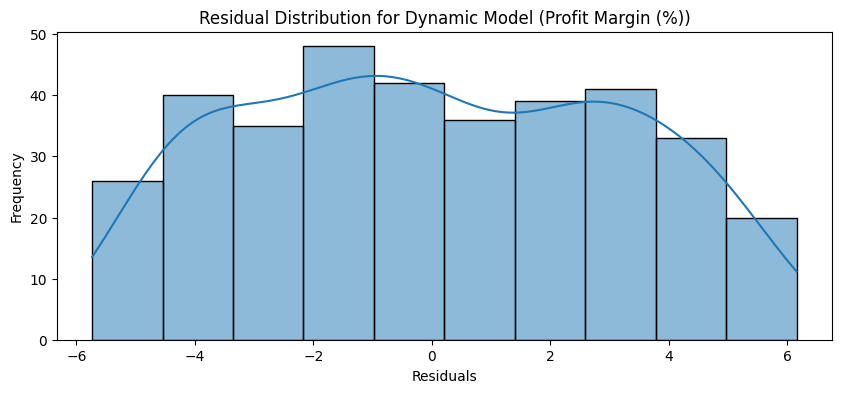

In [ ]:
print("\n--- Residual Diagnostics for Dynamic Panel Models ---")
for dep_var, res_dict in results.items():
    if 'Dynamic' in res_dict:
        model_res = res_dict['Dynamic']
        residuals = model_res.resids
        plt.figure(figsize=(10,4))
        sns.histplot(residuals, kde=True)
        plt.title(f'Residual Distribution for Dynamic Model ({dep_var})')
        plt.xlabel('Residuals')
        plt.ylabel('Frequency')
        plt.show()
    else:
        print(f"Dynamic model results not found for {dep_var}.")